Hands-On Lab: Understanding Training + Mentor Review        
● Step 1: Draw or describe the four-step training loop in a Markdown cell for the project notebook.     
● Step 2: Experiment with a tiny network at three learning rates (too high, too low, good) and plot the loss curves.        
● Step 3: Explain, in your own words, what backpropagation computes and why the chain rule is involved.     
● Step 4: Open a pull request with the current project notebook for the mid-sprint Mentor Code & Notebook 
Review and address the feedback.        

#### Neural Network Training Loop

**Forward pass:** Input data moves through the network and produces predictions.

**Loss calculation:** The predictions are compared with the true labels using a loss function.

**Backpropagation:** The network calculates how much each weight contributed to the error by computing gradients.

**Weight update:** The optimizer changes the weights in the direction that reduces the loss.

This process repeats for many batches and epochs until the model's loss decreases and its predictions improve.

#### Load, Clean & split data:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split , cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score,recall_score, classification_report, confusion_matrix, f1_score

from sklearn.neural_network import MLPClassifier

In [2]:
df = pd.read_csv(r"C:\Users\Masters Computer\Desktop\VScode_For_ Python\internship\Sprint 1\Data\heart_disease.csv" )

In [3]:
print (df.shape,"\n")

print ("Null values: \n", df.isna().sum(),"\n")

print("duplicates :",df.duplicated().sum(),"\n")

(10000, 21) 

Null values: 
 Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64 

duplicates : 0 



In [4]:
print ("Information:")
df.info()

Information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   str    
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   str    
 5   Smoking               9975 non-null   str    
 6   Family Heart Disease  9979 non-null   str    
 7   Diabetes              9970 non-null   str    
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   str    
 10  Low HDL Cholesterol   9975 non-null   str    
 11  High LDL Cholesterol  9974 non-null   str    
 12  Alcohol Consumption   7414 non-null   str    
 13  Stress Level          9978 non-null   str    
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption 

In [5]:
print (df.columns)

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='str')


In [6]:
categorical_cols = df.drop(columns ='Heart Disease Status' ).select_dtypes(include=['str']).columns.tolist()

numerical_cols = df.drop(columns ='Heart Disease Status' ).select_dtypes(include=['int64','float64']).columns.tolist()

print("categorical columns name: ")
print(categorical_cols)

print("\nnumerical columns name: ")
print(numerical_cols)

categorical columns name: 
['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']

numerical columns name: 
['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']


we have some missing values so we deal with them:   

- numeric: fill with median.    
- categorical: fill with mode.    

for Alcohol Consumption we rectify the data since none is a category rather than a null value.

In [7]:
print("Alcohol Consumption categories Before: ", df['Alcohol Consumption'].unique())

# numnerical 
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# categorical
for col in categorical_cols: 
    
    if col == "Alcohol Consumption":
        df[col] = df[col].fillna("Zero")
        
    else:
        df[col] = df[col].fillna(df[col].mode()[0])
    
    
print ("\nAlcohol Consumption categories After: ", df['Alcohol Consumption'].unique())
print ("\nNull values 'after': \n", df.isna().sum(),"\n")


Alcohol Consumption categories Before:  <StringArray>
['High', 'Medium', 'Low', nan]
Length: 4, dtype: str

Alcohol Consumption categories After:  <StringArray>
['High', 'Medium', 'Low', 'Zero']
Length: 4, dtype: str

Null values 'after': 
 Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
Heart Disease Status    0
dtype: int64 



In [8]:
X = df.drop(columns ='Heart Disease Status')
y = df['Heart Disease Status']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify= y)

print(y_train.unique(),"\n")
print(y_train.value_counts(),"\n")
print(y_train.dtype)

<StringArray>
['No', 'Yes']
Length: 2, dtype: str 

Heart Disease Status
No     6400
Yes    1600
Name: count, dtype: int64 

str


#### Backpropagation
 Calculates how much each weight in the neural network contributed to the prediction error.     
  It starts from the loss at the output and works backward through the network, calculating gradients for each weight.      
   These gradients tell the optimizer which direction and how strongly each weight should be changed to reduce the loss.        

   why is the **`chain rule`** involved?    
   Because a weight in an early layer does not directly produce the final loss.

#### Learning Rate Experiment

Three neural networks with the same architecture were trained using different learning rates.       
 A very low learning rate (0.00001), a reasonable learning rate (0.001), and a high learning rate (0.5) were compared.      
  Keeping the architecture and other parameters constant allows the effect of the learning rate on convergence to be observed through the training loss curve.

#### THREE MLP MODELS WITH DIFFERENT LEARNING RATES:

##### Define the models:

- Too low learning rate:

In [10]:
mlp_low = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation="relu",
    solver="sgd",
    learning_rate_init=0.00001,
    batch_size=32,
    max_iter=200,
    random_state=42
)

- Reasonable learning rate

In [11]:
mlp_good = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation="relu",
    solver="sgd",
    learning_rate_init=0.001,
    batch_size=32,
    max_iter=200,
    random_state=42
)

- Too high learning rate

In [12]:
mlp_high = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation="relu",
    solver="sgd",
    learning_rate_init=0.5,
    batch_size=32,
    max_iter=200,
    random_state=42
)

##### Put each model in the same preprocessing pipeline:

In [22]:
preprocessor = ColumnTransformer([("num",  StandardScaler(), numerical_cols)
                                 ,
                                ("col", OneHotEncoder(handle_unknown="ignore"),  categorical_cols)
                                 ])

In [23]:
low_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", mlp_low)
])

good_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", mlp_good)
])

high_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", mlp_high)
])

##### Train the models:

In [14]:
print("Training low learning-rate model...")
low_pipe.fit(X_train, y_train)

print("Training good learning-rate model...")
good_pipe.fit(X_train, y_train)

print("Training high learning-rate model...")
high_pipe.fit(X_train, y_train)

Training low learning-rate model...
Training good learning-rate model...


c:\Users\Masters Computer\Desktop\VScode_For_ Python\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Training high learning-rate model...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U3](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['Age','Gender','Blood Pressure',...,'Fasting Blood Sugar','CRP Level', 'Homocysteine Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('col', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema

##### Get & Plot the loss curve:

In [15]:
low_loss = low_pipe.named_steps["model"].loss_curve_
good_loss = good_pipe.named_steps["model"].loss_curve_
high_loss = high_pipe.named_steps["model"].loss_curve_


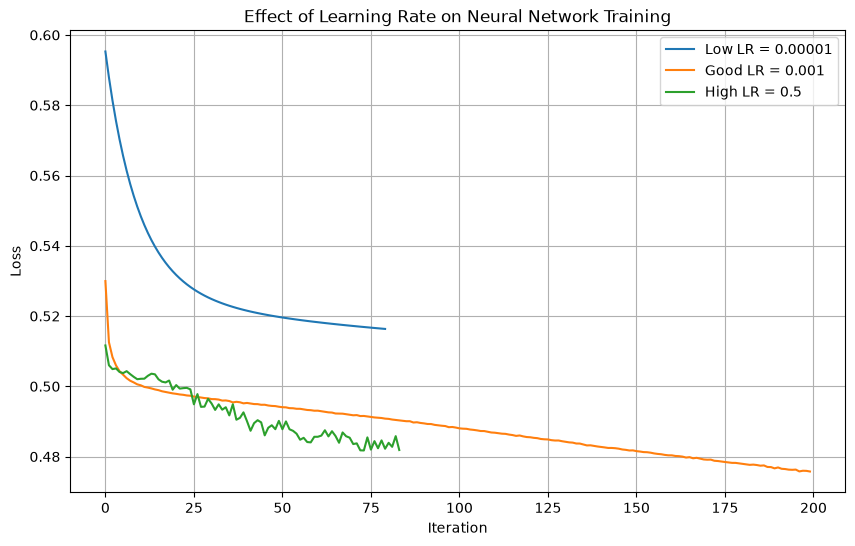

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(low_loss, label="Low LR = 0.00001")
plt.plot(good_loss, label="Good LR = 0.001")
plt.plot(high_loss, label="High LR = 0.5")

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate on Neural Network Training")
plt.legend()
plt.grid()

plt.show()

##### The 3 models Final comparison :

- Training Losses

In [17]:
print("\nFinal Training Losses")

print("Low LR final loss: ", low_loss[-1])
print("Good LR final loss:", good_loss[-1])
print("High LR final loss:", high_loss[-1])


Final Training Losses
Low LR final loss:  0.5163393521877178
Good LR final loss: 0.47575905044118105
High LR final loss: 0.481872444876529


- Number of Iterations

In [18]:
print("\nNumber of Training Iterations")

print("Low LR iterations: ", len(low_loss))
print("Good LR iterations:", len(good_loss))
print("High LR iterations:", len(high_loss))



Number of Training Iterations
Low LR iterations:  80
Good LR iterations: 200
High LR iterations: 84


- Accuracy

In [19]:
low_pred = low_pipe.predict(X_test)
good_pred = good_pipe.predict(X_test)
high_pred = high_pipe.predict(X_test)

print("\nTest Accuracy")

print("Low LR accuracy: ",
      accuracy_score(y_test, low_pred))

print("Good LR accuracy:",
      accuracy_score(y_test, good_pred))

print("High LR accuracy:",
      accuracy_score(y_test, high_pred))


Test Accuracy
Low LR accuracy:  0.8005
Good LR accuracy: 0.799
High LR accuracy: 0.7905


- CLASSIFICATION REPORT FOR THE GOOD LEARNING RATE

In [21]:
print("\nClassification Report - Good Learning Rate")

print( classification_report(y_test, good_pred) )


Classification Report - Good Learning Rate
              precision    recall  f1-score   support

          No       0.80      1.00      0.89      1600
         Yes       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000

